In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
from langgraph.graph import START, END, StateGraph
from langchain_ollama import ChatOllama
from langgraph.types import interrupt, Command
from pydantic import BaseModel
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [5]:
llm = ChatOllama(model="gemma4:31b-cloud")

In [6]:
class MailState(BaseModel):
    query: str = ""
    draft: str = ""
    human_feedback: str = ""
    final_response: str = ""

In [7]:
# Defining nodes


def draft_mail(state: MailState) -> MailState:
    if state.draft:
        prompt = f"""
        Rewrite the email below.

        Original request:
        {state.query}

        Current email:
        {state.draft}

        Required change:
        Replace the leave dates with 3rd August to 5th August.

        Return only the complete revised email.
        """
        draft = llm.invoke(prompt).content
    else:
        draft = llm.invoke(state.query).content

    state.draft = draft
    return state


def human_feedback(state: MailState) -> MailState:
    feedback = interrupt(
        {
            "draft": state.draft,
            "question": "Do you want to continue or rewrite the mail?",
        }
    )

    fb = (feedback or "").strip().lower()
    if fb in ("continue", "approve", "yes", "ok"):
        state.human_feedback = ""
        return state
    else:
        state.human_feedback = feedback
        return state


def final_response(state: MailState) -> MailState:
    if state.human_feedback:
        state.final_response = state.human_feedback
        return state
    else:
        print("Email sent successfully...")
        state.final_response = "Email sent successfully!"
        return state


def condition_routing(
    state: MailState,
) -> Literal["draft_mail_node", "final_response_node"]:
    if state.human_feedback:
        return "draft_mail_node"

    return "final_response_node"

In [8]:
graph = StateGraph(MailState)

# node
graph.add_node("draft_mail_node", draft_mail)
graph.add_node("human_feedback_node", human_feedback)
graph.add_node("final_response_node", final_response)

# edge
graph.add_edge(START, "draft_mail_node")
graph.add_edge("draft_mail_node", "human_feedback_node")
graph.add_conditional_edges("human_feedback_node", condition_routing)
graph.add_edge("final_response_node", END)

graph = graph.compile(checkpointer=InMemorySaver())

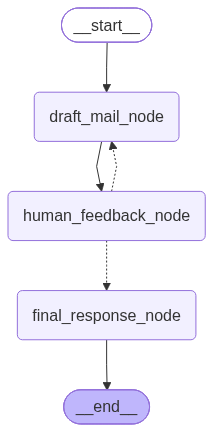

In [40]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [9]:
config = {"configurable": {"thread_id": "human_in_the_loop_test"}}

In [10]:
res = graph.invoke(
    {
        "query": "Create a email to send for medical leave request from 2nd to 5th August to manager."
    },
    config=config,
)
print(res["draft"])

Depending on your relationship with your manager and your company culture, you may want a different tone. Here are three options: a **professional/formal** version, a **short/direct** version, and a **detailed** version.

### Option 1: Professional & Formal
*Best for corporate environments or if you have a formal relationship with your manager.*

**Subject:** Medical Leave Request - [Your Full Name]

Dear [Manager's Name],

I am writing to formally request a medical leave of absence from **August 2nd to August 5th**. I expect to return to work on [Date of return, e.g., August 6th].

I will ensure that all my current tasks are up to date before my leave begins. During my absence, [Colleague's Name] has kindly agreed to be the point of contact for [mention specific project or task] to ensure a smooth workflow.

I have attached my medical certificate for your records [only include this if you have one/it is required]. 

Thank you for your understanding.

Best regards,

[Your Name]
[Your J

In [14]:
res = graph.invoke(
    Command(
        resume="Replace the leave dates 2nd August to 5th August with 3rd August to 5th August."
    ),
    config=config,
)

print(res["draft"])

Depending on your relationship with your manager and your company culture, you may want a different tone. Here are three options: a **professional/formal** version, a **short/direct** version, and a **detailed** version.

### Option 1: Professional & Formal
*Best for corporate environments or if you have a formal relationship with your manager.*

**Subject:** Medical Leave Request - [Your Full Name]

Dear [Manager's Name],

I am writing to formally request a medical leave of absence from **August 3rd to August 5th**. I expect to return to work on [Date of return, e.g., August 6th].

I will ensure that all my current tasks are up to date before my leave begins. During my absence, [Colleague's Name] has kindly agreed to be the point of contact for [mention specific project or task] to ensure a smooth workflow.

I have attached my medical certificate for your records [only include this if you have one/it is required]. 

Thank you for your understanding.

Best regards,

[Your Name]
[Your J

In [17]:
res = graph.invoke(
    Command(resume="continue"),
    config=config,
)
res

{'query': 'Create a email to send for medical leave request from 2nd to 5th August to manager.',
 'draft': 'Depending on your relationship with your manager and your company culture, you may want a different tone. Here are three options: a **professional/formal** version, a **short/direct** version, and a **detailed** version.\n\n### Option 1: Professional & Formal\n*Best for corporate environments or if you have a formal relationship with your manager.*\n\n**Subject:** Medical Leave Request - [Your Full Name]\n\nDear [Manager\'s Name],\n\nI am writing to formally request a medical leave of absence from **August 3rd to August 5th**. I expect to return to work on [Date of return, e.g., August 6th].\n\nI will ensure that all my current tasks are up to date before my leave begins. During my absence, [Colleague\'s Name] has kindly agreed to be the point of contact for [mention specific project or task] to ensure a smooth workflow.\n\nI have attached my medical certificate for your records 